In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(9994, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 1

In [5]:
print(df.duplicated().sum())

0


In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10


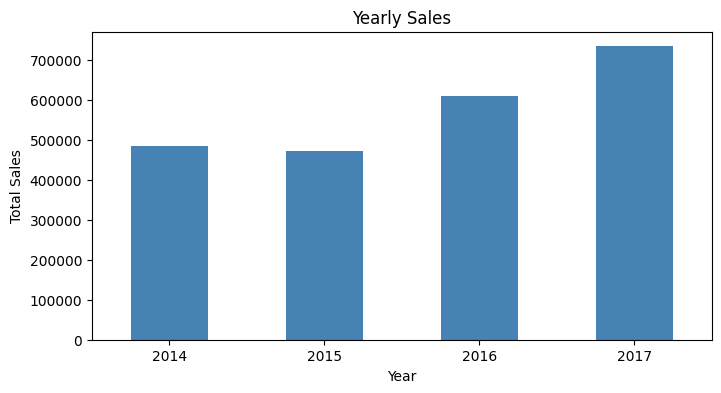

In [8]:
df.groupby('Year')['Sales'].sum().plot(kind='bar', figsize=(8,4), color='steelblue')
plt.title('Yearly Sales')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

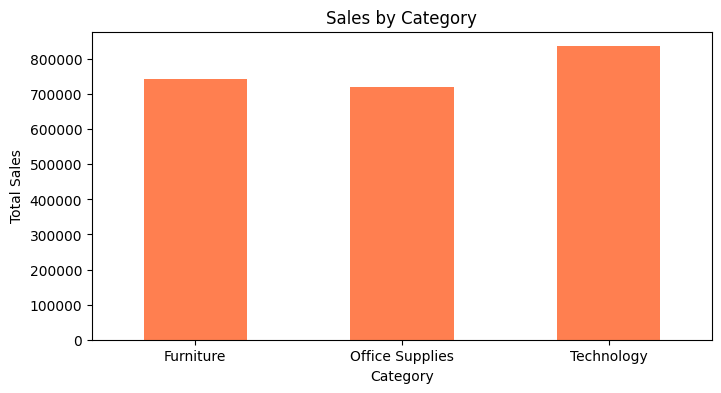

In [9]:
df.groupby('Category')['Sales'].sum().plot(kind='bar', figsize=(8,4), color='coral')
plt.title('Sales by Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

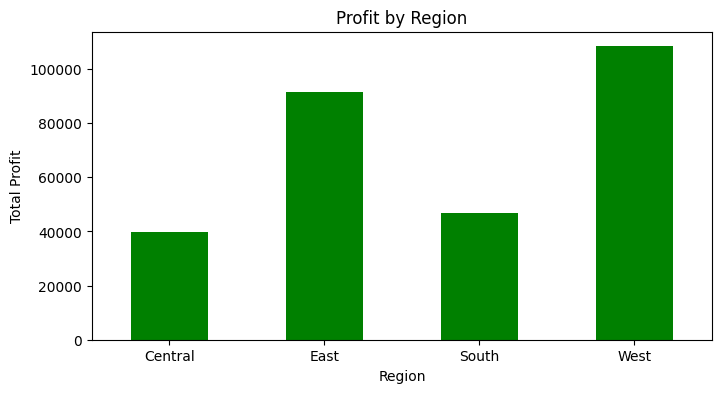

In [10]:
df.groupby('Region')['Profit'].sum().plot(kind='bar', figsize=(8,4), color='green')
plt.title('Profit by Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.show()

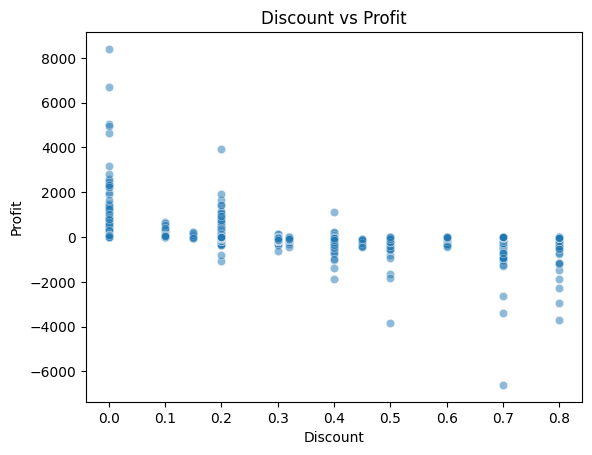

In [11]:
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.5)
plt.title('Discount vs Profit')
plt.show()

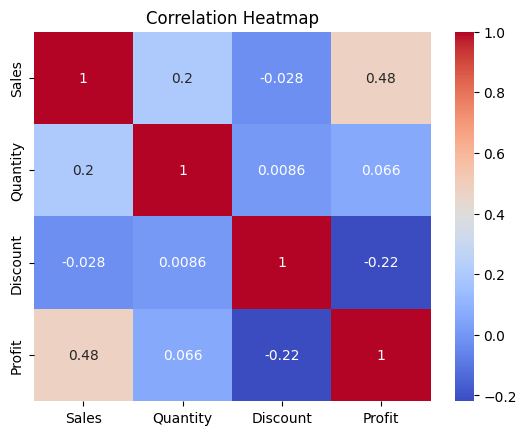

In [12]:
sns.heatmap(df[['Sales', 'Quantity', 'Discount', 'Profit']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Category_enc'] = le.fit_transform(df['Category'])
df['Region_enc'] = le.fit_transform(df['Region'])
df['Segment_enc'] = le.fit_transform(df['Segment'])

X = df[['Quantity', 'Discount', 'Category_enc', 'Region_enc', 'Segment_enc']]
y = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(7995, 5) (1999, 5)


In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MAE: 73.43196124279669
R² Score: 0.07233111934991765


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R² Score:", r2_score(y_test, y_pred_rf))

MAE: 70.5504198692189
R² Score: -0.04299150762397641


In [16]:
X = df[['Quantity', 'Discount', 'Category_enc', 'Region_enc', 'Segment_enc']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model2.fit(X_train, y_train)

y_pred2 = rf_model2.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred2))
print("R² Score:", r2_score(y_test, y_pred2))

MAE: 242.33664678810936
R² Score: 0.05986162768299974


In [17]:
df['month'] = df['Order Date'].dt.month
df['day_of_week'] = df['Order Date'].dt.dayofweek
df['Ship_Mode_enc'] = le.fit_transform(df['Ship Mode'])
df['Sub_Category_enc'] = le.fit_transform(df['Sub-Category'])

X = df[['Quantity', 'Discount', 'Category_enc', 'Region_enc', 
        'Segment_enc', 'Ship_Mode_enc', 'Sub_Category_enc', 'month', 'day_of_week']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model3 = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf_model3.fit(X_train, y_train)

y_pred3 = rf_model3.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred3))
print("R² Score:", r2_score(y_test, y_pred3))

MAE: 218.5495734680303
R² Score: 0.1802213542315293


In [18]:
df['Profit_Margin'] = df['Profit'] / df['Sales']

X = df[['Quantity', 'Discount', 'Category_enc', 'Region_enc', 
        'Segment_enc', 'Ship_Mode_enc', 'Sub_Category_enc', 'month']]
y = df['Profit_Margin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model4 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model4.fit(X_train, y_train)

y_pred4 = rf_model4.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred4))
print("R² Score:", r2_score(y_test, y_pred4))

MAE: 0.07328319859828422
R² Score: 0.9447714400508461


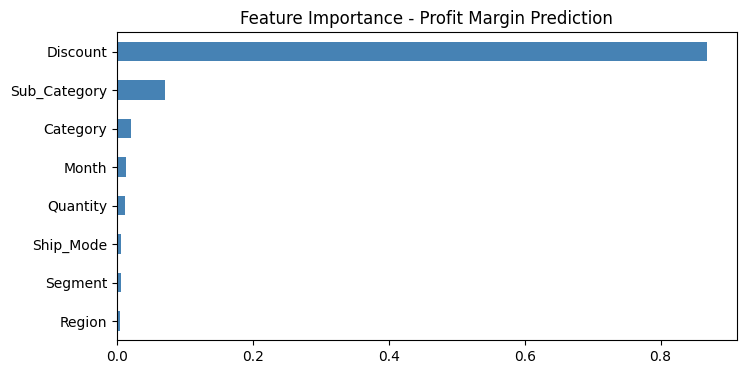

In [19]:
feat_importance = pd.Series(rf_model4.feature_importances_, 
                            index=['Quantity','Discount','Category','Region',
                                   'Segment','Ship_Mode','Sub_Category','Month'])

feat_importance.sort_values().plot(kind='barh', color='steelblue', figsize=(8,4))
plt.title('Feature Importance - Profit Margin Prediction')
plt.show()